# Analysing both the datasets

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu


df1 = pd.read_csv('./dataset1_cleaned.csv', parse_dates=True)
df2 = pd.read_csv('./dataset2_cleaned.csv', parse_dates=True)


ModuleNotFoundError: No module named 'scipy'

In [ ]:
df1.head()

,start_time,bat_landing_to_food_min,habit,rat_period_start,rat_period_end,min_after_rat_arrival,risk,reward,month,sunset_time,min_after_sunset,season,date,chronology_check
0,2017-12-26 20:57:00,0.016667,Unknown,2017-12-26 20:53:00,2017-12-26 20:58:00,3.983333,0,0,0,2017-12-26 16:43:00,254.916667,0,2017-12-26,True
1,2017-12-26 20:57:00,0.083333,Unknown,2017-12-26 20:53:00,2017-12-26 20:58:00,3.316667,0,0,0,2017-12-26 16:43:00,254.250000,0,2017-12-26,True
2,2017-12-26 21:24:00,0.050000,fast,2017-12-26 21:22:00,2017-12-26 21:27:00,2.016667,0,1,0,2017-12-26 16:43:00,281.616667,0,2017-12-26,True
3,2017-12-26 21:24:00,0.250000,rat,2017-12-26 21:22:00,2017-12-26 21:27:00,1.466667,1,0,0,2017-12-26 16:43:00,281.066667,0,2017-12-26,True
4,2017-12-26 21:24:00,0.100000,pick,2017-12-26 21:22:00,2017-12-26 21:27:00,1.883333,0,1,0,2017-12-26 16:43:00,281.483333,0,2017-12-26,True


In [ ]:
df2.head()

,time,month,bat_landing_number,food_availability,rat_minutes,rat_arrival_number,minutes_after_sunset,date
0,2017-12-26 16:13:00,0,20,4.000000,0.0,0,-30.0,2017-12-26
1,2017-12-26 16:43:00,0,28,4.000000,0.0,0,0.0,2017-12-26
2,2017-12-26 17:13:00,0,25,4.000000,0.0,0,30.0,2017-12-26
3,2017-12-26 17:43:00,0,71,4.000000,0.0,0,60.0,2017-12-26
4,2017-12-26 18:13:00,0,44,3.753857,0.0,0,90.0,2017-12-26


### Calculating Number of Bat landing per 30min time interval
bat_landing_number in dataset2 contains the sequence for individual bat landing. So, we are now grouping the bat landing with interval_time then counting bats per 30-min interval from dataset 1.

In [ ]:
df1['start_time'] = pd.to_datetime(df1['start_time'])
df1['interval_time'] = df1['start_time'].dt.floor('30min')

# Counting bats per 30 min
bat_count = (df1.groupby(['date', 'interval_time']).size().rename('bat_count').reset_index())

# Merging that count back to each bat row 
df1 = df1.merge(bat_count, on=['date', 'interval_time'], how='left')
df1.head()

,start_time,bat_landing_to_food_min,habit,rat_period_start,rat_period_end,min_after_rat_arrival,risk,reward,month,sunset_time,min_after_sunset,season,date,chronology_check,interval_time,bat_count
0,2017-12-26 20:57:00,0.016667,Unknown,2017-12-26 20:53:00,2017-12-26 20:58:00,3.983333,0,0,0,2017-12-26 16:43:00,254.916667,0,2017-12-26,True,2017-12-26 20:30:00,2
1,2017-12-26 20:57:00,0.083333,Unknown,2017-12-26 20:53:00,2017-12-26 20:58:00,3.316667,0,0,0,2017-12-26 16:43:00,254.250000,0,2017-12-26,True,2017-12-26 20:30:00,2
2,2017-12-26 21:24:00,0.050000,fast,2017-12-26 21:22:00,2017-12-26 21:27:00,2.016667,0,1,0,2017-12-26 16:43:00,281.616667,0,2017-12-26,True,2017-12-26 21:00:00,7
3,2017-12-26 21:24:00,0.250000,rat,2017-12-26 21:22:00,2017-12-26 21:27:00,1.466667,1,0,0,2017-12-26 16:43:00,281.066667,0,2017-12-26,True,2017-12-26 21:00:00,7
4,2017-12-26 21:24:00,0.100000,pick,2017-12-26 21:22:00,2017-12-26 21:27:00,1.883333,0,1,0,2017-12-26 16:43:00,281.483333,0,2017-12-26,True,2017-12-26 21:00:00,7


# Joining Two Datasets

In [ ]:
# Ensuring both the column are in datetime format and sorting 
df1['start_time'] = pd.to_datetime(df1['start_time']).sort_values(ascending=True)
df2['time'] = pd.to_datetime(df2['time']).sort_values(ascending=True)

# Merging df1 and df2 on date
# data = pd.merge(df1,df2, left_on='date', right_on='date', how='left')
#  merge ran into row explosion

In [ ]:
# Merging df1 and df2 
data = pd.merge_asof(df1, df2, left_on='interval_time', right_on='time', direction='backward')

In [ ]:
data.info()
data.isnull().sum()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   start_time               906 non-null    datetime64[ns]
 1   bat_landing_to_food_min  906 non-null    float64       
 2   habit                    906 non-null    object        
 3   rat_period_start         906 non-null    object        
 4   rat_period_end           906 non-null    object        
 5   min_after_rat_arrival    906 non-null    float64       
 6   risk                     906 non-null    int64         
 7   reward                   906 non-null    int64         
 8   month_x                  906 non-null    int64         
 9   sunset_time              906 non-null    object        
 10  min_after_sunset         906 non-null    float64       
 11  season                   906 non-null    int64         
 12  date_x                   906 non-nul

,start_time,bat_landing_to_food_min,habit,rat_period_start,rat_period_end,min_after_rat_arrival,risk,reward,month_x,sunset_time,...,interval_time,bat_count,time,month_y,bat_landing_number,food_availability,rat_minutes,rat_arrival_number,minutes_after_sunset,date_y
0,2017-12-26 20:57:00,0.016667,Unknown,2017-12-26 20:53:00,2017-12-26 20:58:00,3.983333,0,0,0,2017-12-26 16:43:00,...,2017-12-26 20:30:00,2,2017-12-26 20:13:00,0,32,3.000000,0.0,0,210.0,2017-12-26
1,2017-12-26 20:57:00,0.083333,Unknown,2017-12-26 20:53:00,2017-12-26 20:58:00,3.316667,0,0,0,2017-12-26 16:43:00,...,2017-12-26 20:30:00,2,2017-12-26 20:13:00,0,32,3.000000,0.0,0,210.0,2017-12-26
2,2017-12-26 21:24:00,0.050000,fast,2017-12-26 21:22:00,2017-12-26 21:27:00,2.016667,0,1,0,2017-12-26 16:43:00,...,2017-12-26 21:00:00,7,2017-12-26 20:43:00,0,51,2.968874,0.0,2,240.0,2017-12-26
3,2017-12-26 21:24:00,0.250000,rat,2017-12-26 21:22:00,2017-12-26 21:27:00,1.466667,1,0,0,2017-12-26 16:43:00,...,2017-12-26 21:00:00,7,2017-12-26 20:43:00,0,51,2.968874,0.0,2,240.0,2017-12-26
4,2017-12-26 21:24:00,0.100000,pick,2017-12-26 21:22:00,2017-12-26 21:27:00,1.883333,0,1,0,2017-12-26 16:43:00,...,2017-12-26 21:00:00,7,2017-12-26 20:43:00,0,51,2.968874,0.0,2,240.0,2017-12-26


# Objective
Do bats perceive rats not just as competitors for food but also as potential predators? 

## Our Logic:
1. Calculate rat_present to determine, rat presence on food platform during bat landing. 
2. Calculate rat_more_than_bat to determine, if num of rat > num of bat on food platform during bat landing. 
3. Grouping data based on rat_present and rat_more_than_bat to determine the average risk taking behavior of bat. 
4. Calculating bat average time to food when rat was present and absence.
5. Comparing food availability with risk taken by bat, based on rat_more_than_bat

### Confirming the rat presence during bat landing
In this section,we are confirming if there was rat on food platform when bat landed. 

In [87]:
# #Method 1
# data['rat_present'] = (
#     (data['start_time'] >= data['rat_period_start']) &
#     (data['start_time'] <= data['rat_period_end'])
# )
# data['rat_present'] = data['rat_present'].astype(int)


# Method 2
data['rat_present'] = data['rat_arrival_number'].fillna(0) > 0
data['rat_present'] = data['rat_present'].astype(int)
data['rat_present'].value_counts()

rat_present
1    569
0    337
Name: count, dtype: int64

We have merged our dataset based on the interval time and time, which both are in 30 min interval. This is why we chose to rat arrival to determine rat presence. If rat arrival number is > 0 for given 30 min interval, we are considering the presence of rat on food platform

### Comparing number of rats vs number of bats

In [88]:
data['rats_more_than_bats'] = (data['rat_arrival_number'] > data['bat_count']).astype(int)
data['rats_more_than_bats'].unique()

array([0, 1])

### Calcualting risk taken behavior of bat 
We have calculated risk taken behavior of bat in dfferenct situation. When rat was present and absent

In [94]:
risk_behavior = data.groupby(['rat_present', 'rats_more_than_bats']).agg(
    avg_risk = ('risk', 'mean'),
    count = ('start_time', 'count')
).reset_index()
risk_behavior

,rat_present,rats_more_than_bats,avg_risk,count
0,0,0,0.486647,337
1,1,0,0.495430,547
2,1,1,0.590909,22


Bats took slightly more risks when rats outnumbered bats (59%), compared to when rats were fewer or absent (~49%). However, this result is based on a very small sample (22 cases), so it should be treated cautiously

### Calculating Bat average time to food

In [ ]:
avg_time_to_food = data['bat_landing_to_food_min'].mean()
avg_time_to_food

np.float64(0.09217830177121043)

### Bat Average time to food during the presence of rat

In [90]:
avg_time_to_food_inpresence_rat = data.groupby('rat_present')['bat_landing_to_food_min'].mean()
avg_time_to_food_inpresence_rat

rat_present
0    0.091965
1    0.092304
Name: bat_landing_to_food_min, dtype: float64

# Food Availability Unit
We have given food availability data but the unit is unkown. So we are truning given data into fraction of 4, so it's easy to interpret. Zero (0) represent no food and 1 represent food. 

In [91]:
data['food_fraction'] = (data['food_availability'] / 4).round(2) 
data['food_fraction'].unique()

array([0.75, 0.74, 0.25, 0.24, 0.89, 1.  , 0.88, 0.5 , 0.71, 0.7 , 0.99,
       0.4 , 0.91, 0.54, 0.38, 0.48, 0.62, 0.36, 0.26, 0.51, 0.76, 0.35,
       0.83, 0.33, 0.46, 0.72, 0.32, 0.56, 0.97, 0.64, 0.49, 0.77, 0.9 ,
       0.52, 0.63, 0.73, 0.37, 0.65, 0.47, 0.87, 0.61, 0.59, 0.6 , 0.58,
       0.69])

# Calculating Risk Level
Now we have risk taken behavior and food availability unit. We are calculating risk taken level for bat. We want to identify if bat took more risk when number of rat is greater than number of bat or vice versa. Similarly, availability of food during the risk taken.

### Combining both rat and food context

In [95]:
summary = data.groupby(['risk', 'rats_more_than_bats']).agg(
    avg_food_fraction = ('food_fraction', 'mean'),
    avg_bat_to_food = ('bat_landing_to_food_min', 'mean'),
    count = ('start_time', 'count')
).reset_index()
summary

,risk,rats_more_than_bats,avg_food_fraction,avg_bat_to_food,count
0,0,0,0.644187,0.069113,449
1,0,1,0.688889,0.048354,9
2,1,0,0.658759,0.115966,435
3,1,1,0.671538,0.123183,13


# Visualization Above comparision


### Plotting Risk taking Behavior of Bat
We are plotting risk taking behavior of bat based on rat_present and rats_more_than_bats

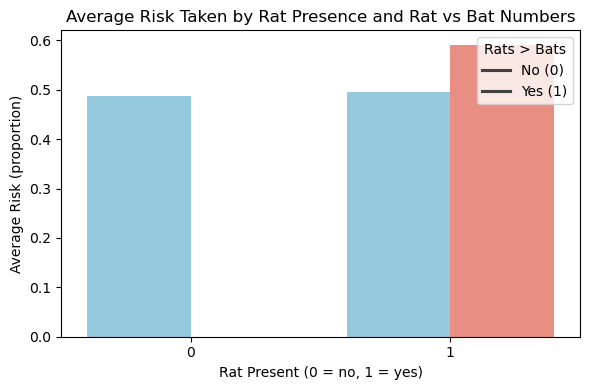

In [96]:
plt.figure(figsize=(6,4))
sns.barplot(
    x="rat_present",
    y="avg_risk",
    hue="rats_more_than_bats",
    data=risk_behavior,
    palette=["skyblue", "salmon"]
)
plt.title("Average Risk Taken by Rat Presence and Rat vs Bat Numbers")
plt.xlabel("Rat Present (0 = no, 1 = yes)")
plt.ylabel("Average Risk (proportion)")
plt.legend(title="Rats > Bats", labels=["No (0)", "Yes (1)"])
plt.tight_layout()
plt.show()

### Plotting Average time to food for bat
We are plotting average time taken by bat from landing to start moving to food platform, during the presence of rat and absence of rat.

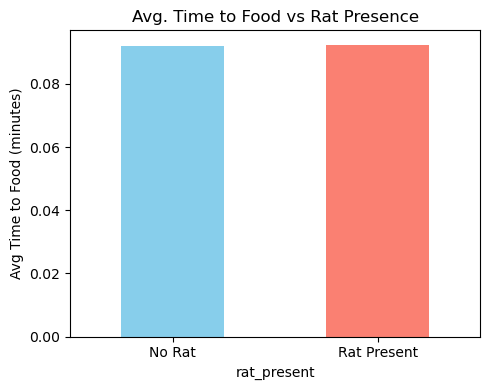

In [97]:

# Group by rat presence and compute mean feeding time
avg_time = data.groupby("rat_present")["bat_landing_to_food_min"].mean()

# Plot
plt.figure(figsize=(5,4))
avg_time.plot(kind="bar", color=["skyblue", "salmon"])
plt.title("Avg. Time to Food vs Rat Presence")
plt.ylabel("Avg Time to Food (minutes)")
plt.xticks([0,1], ["No Rat", "Rat Present"], rotation=0)
plt.tight_layout()
plt.show()


### Plotting Risk taken by Bat
Risk taken by bat compared to num of rat and food availability

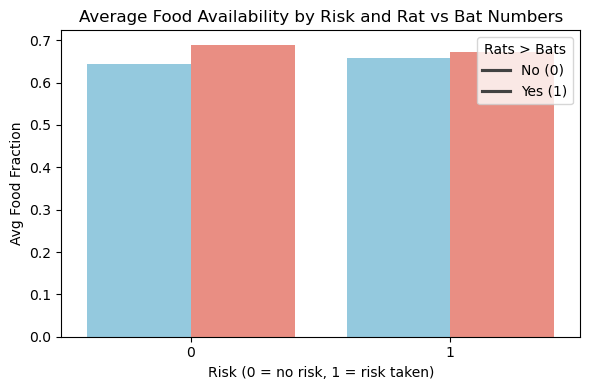

In [98]:
plt.figure(figsize=(6,4))
sns.barplot(
    x="risk", 
    y="avg_food_fraction", 
    hue="rats_more_than_bats", 
    data=summary,
    palette=["skyblue", "salmon"]
)
plt.title("Average Food Availability by Risk and Rat vs Bat Numbers")
plt.xlabel("Risk (0 = no risk, 1 = risk taken)")
plt.ylabel("Avg Food Fraction")
plt.legend(title="Rats > Bats", labels=["No (0)", "Yes (1)"])
plt.tight_layout()
plt.show()

# Statistical Testing

### For Average time to food when rat present vs rat absence

In [ ]:

# Split into groups
group_no_rat  = data.loc[data['rat_present']==0, 'bat_landing_to_food_min'].dropna()
group_rat     = data.loc[data['rat_present']==1, 'bat_landing_to_food_min'].dropna()

# Independent t-test (assumes roughly normal distribution)
t_stat, p_val = ttest_ind(group_no_rat, group_rat, equal_var=False)

print("T-test result:")
print(f"t-statistic = {t_stat:.3f}, p-value = {p_val:.3g}")

# If distributions look skewed, also try non-parametric Mann-Whitney U
u_stat, p_val_u = mannwhitneyu(group_no_rat, group_rat, alternative='two-sided')

print("\nMann-Whitney U test result:")
print(f"U-statistic = {u_stat:.3f}, p-value = {p_val_u:.3g}")
